In [2]:
import sqlite3
import pandas
import numpy as np
sqlite_file = 'lahman_1871-2022.sqlite'
conn = sqlite3.connect(sqlite_file)
# Extracting the baseball data from the sqlite file hosted at https://github.com/jknecht/baseball-archive-sqlite/releases/tag/2022


## Part 1: Wrangling
Printing out names of all tables present in the SQLite database object 'lahman_1871-2022.sqlite'

In [3]:
table_query="SELECT name FROM sqlite_master WHERE type='table';" 
table_df = pandas.read_sql(table_query, conn)
table_df

,name
0,AllstarFull
1,Appearances
2,AwardsManagers
3,AwardsPlayers
4,AwardsShareManagers
5,AwardsSharePlayers
6,Batting
7,BattingPost
8,CollegePlaying
9,Fielding


#### Computing a relation containing the total payroll and winning percentage for each team
This code defines a SQL query that retrieves team performance and payroll data 
from the Salaries and Teams tables for the years 1990 to 2014. It calculates 
each team's total payroll and win percentage by dividing wins by total games played. 

The results are grouped by year and team, which are then read into a pandas DataFrame using the SQLite database connection.

In [5]:
winning_perc_query="""SELECT 
    t1.yearID,
    t1.teamID,
    t2.franchID,
    t2.W AS Wins,
    t2.G AS GamesPlayed,
    (SUM(t1.salary)) AS TotalPayroll,
    ((t2.W * 100.0) / t2.G) AS WinningPercentage
FROM 
    Salaries t1
JOIN 
    Teams t2
ON 
    t1.yearID = t2.yearID
    AND t1.teamID = t2.teamID
    AND t1.lgID = t2.lgID
    WHERE (t1.yearID) BETWEEN 1990 and 2014
GROUP BY 
    t1.yearID, t1.teamID
ORDER BY 
    t1.yearID, t1.teamID;"""

winning_perc_df = pandas.read_sql(winning_perc_query, conn)
winning_perc_df

,yearID,teamID,franchID,Wins,GamesPlayed,TotalPayroll,WinningPercentage
0,1990,ATL,ATL,65,162,14555501.0,40.123457
1,1990,BAL,BAL,76,161,9680084.0,47.204969
2,1990,BOS,BOS,88,162,20558333.0,54.320988
3,1990,CAL,ANA,80,162,21720000.0,49.382716
4,1990,CHA,CHW,94,162,9491500.0,58.024691
...,...,...,...,...,...,...,...
723,2014,SLN,STL,90,162,120693000.0,55.555556
724,2014,TBA,TBD,77,162,72689100.0,47.530864
725,2014,TEX,TEX,67,162,112255059.0,41.358025
726,2014,TOR,TOR,83,162,109920100.0,51.234568


Type of Join Used: INNER JOIN

I used an INNER JOIN to combine the Salaries and Teams tables. This type of join ensures that only rows where the yearID, teamID, and lgID match in both tables are included in the final relation. If there is missing data in either table for a particular team or year, those rows are excluded from the result.

Reason for using INNER JOIN:

Handling missing data: By using an INNER JOIN, I effectively filtered out cases where data from either table is missing. For instance:
If a team has no salary records for a given year, that team will be excluded.
If a team has no performance stats (games played or wins), that team will also be excluded.
This approach avoids returning rows with incomplete data, which could skew calculations like total payroll or winning percentage.

## Part 2: Exploratory Data Analysis

#### Problem 2

<b> Distribution of payrolls across teams conditioned on time </b> <br>
This code uses Matplotlib and Seaborn to plot a line graph showing the distribution of payrolls across teams. For each unique team in the dataset, a line representing its total payroll over the years is plotted using for-loop

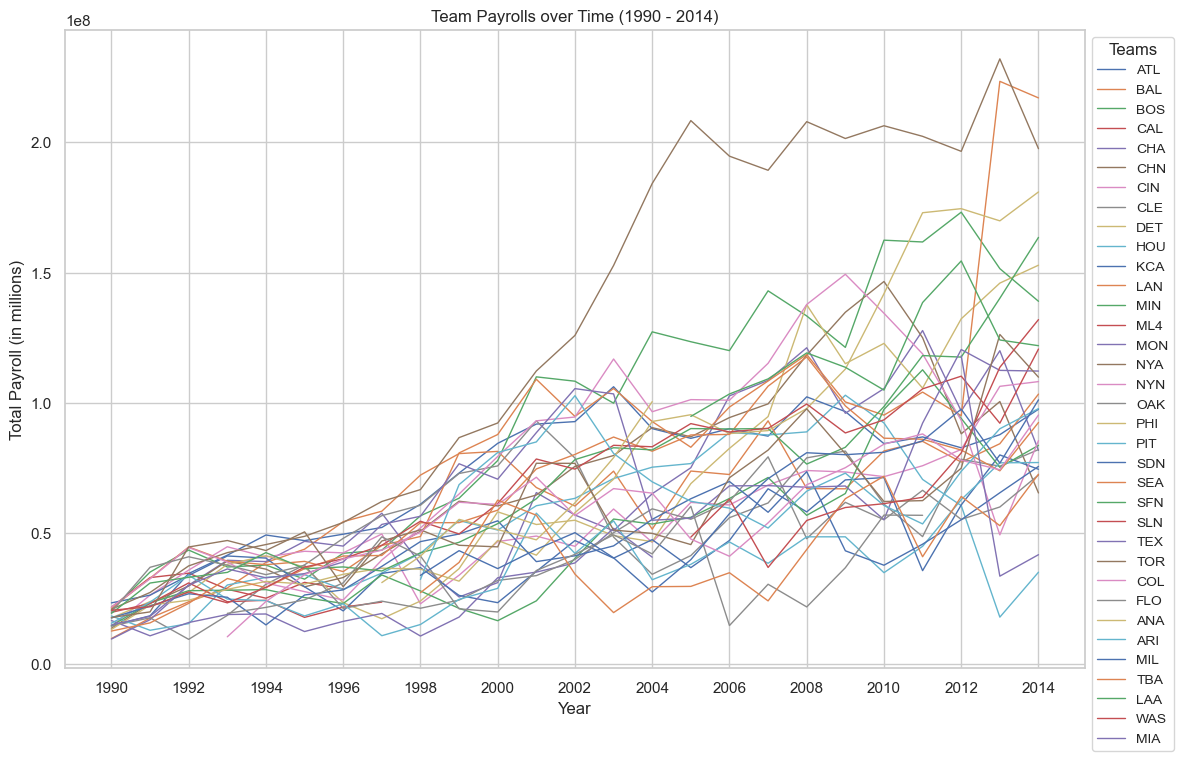

In [106]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Columns should include: 'yearID', 'teamID', 'TotalPayroll'

df = winning_perc_df
# Filter data between 1990 and 2014 again for sanity check 
df_filtered = df[(df['yearID'] >= 1990) & (df['yearID'] <= 2014)]

# Set the plot style for better aesthetics
sns.set(style="whitegrid")

# Create the line plot for each team
plt.figure(figsize=(12, 8))

# Plotting a line for each team's payroll over the years
for team in df_filtered['teamID'].unique():
    team_data = df_filtered[df_filtered['teamID'] == team]
    plt.plot(team_data['yearID'], team_data['TotalPayroll'], label=team, linewidth=1)

# Adding labels and title
plt.xlabel('Year')
plt.ylabel('Total Payroll (in millions)')
plt.title('Team Payrolls over Time (1990 - 2014)')
plt.xticks(range(1990, 2015, 2))  # Setting x-ticks for every 2 years

# Optional: Add a legend outside the plot for team labels
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), title='Teams', fontsize='small')

# Display the plot
plt.tight_layout()
plt.show()


#### Question 1:

We notice that the payrolls have steadily increased over the years, which means that the mean payroll has also increased on a yearly basis.
The below plot illustrates this phenomenon.

#### Problem 3:
Plot of mean team payrolls over time

This code creates a line plot displaying the mean, median, maximum, and minimum payrolls of teams from 1990 to 2014. As answered in question 1, this plot proves that there is trend for payrolls to increase over time.
The x-axis showing the years and the y-axis represents payroll in millions

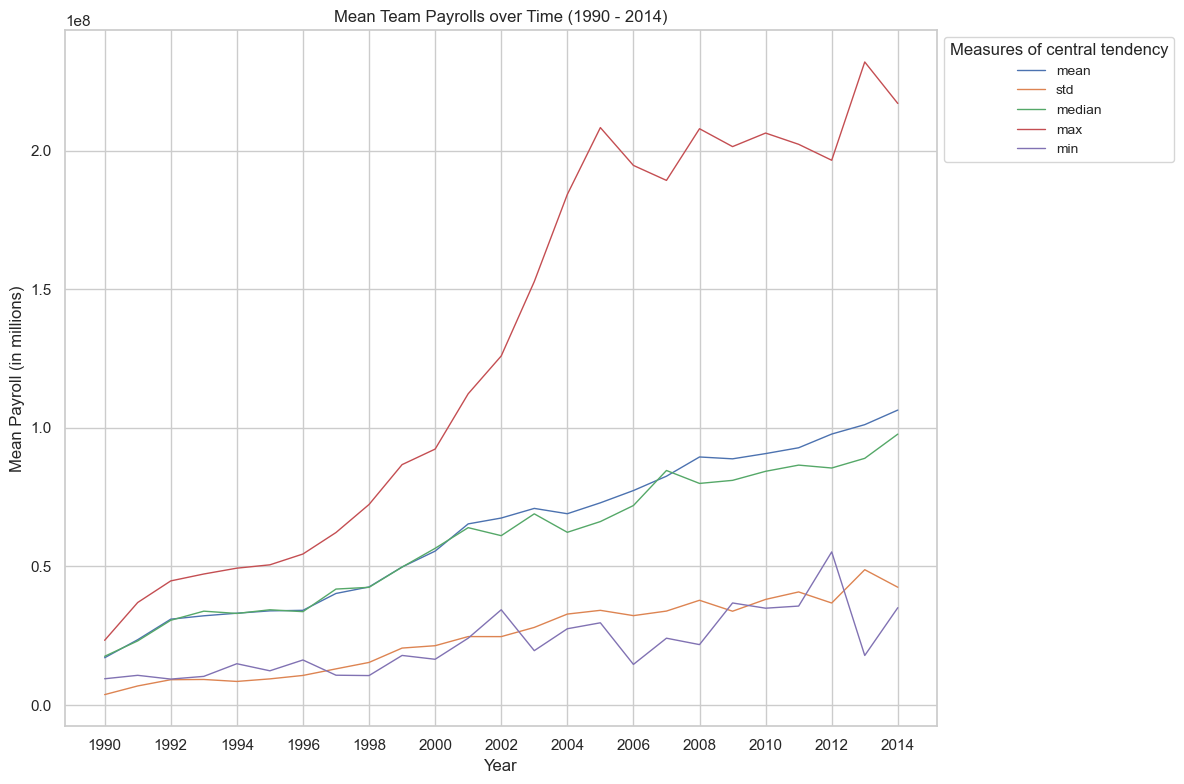

In [107]:
# Set the plot style for better aesthetics
sns.set(style="whitegrid")

# Create the line plot for each team
plt.figure(figsize=(12, 8))

# Plotting a line for each team's payroll over the years
mean_df=df_filtered.groupby('yearID')['TotalPayroll'].agg(['mean', 'std', 'median','max','min'])
mean_df.columns = [ 'avg_payroll','std', 'median','max','min']

plt.plot(mean_df.index, mean_df, label=['mean','std','median','max','min'], linewidth=1)

# Adding labels and title
plt.xlabel('Year')
plt.ylabel('Mean Payroll (in millions)')
plt.title('Mean Team Payrolls over Time (1990 - 2014)')
plt.xticks(range(1990, 2015, 2))  # Setting x-ticks for every 2 years

# Optional: Add a legend outside the plot for team labels
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), title='Measures of central tendency', fontsize='small')

# Display the plot
plt.tight_layout()
plt.show()


<b> General Growth in Payrolls Over Time:</b> <br>
1) There is a noticeable increase in payrolls across all teams from 1990 to 2014. <br>
2) In the early 1990s, most teams' payrolls were relatively close to each other, clustered between approximately 20 million and 50 million. <br>
3) By 2014, many teams’ payrolls had risen dramatically, with several teams spending over 200 million annually, while others stayed closer to $100 million or below. <br>

<b> Central Tendency (Mean/Median): </b> <br>
1) From 1990 to around 2000, most teams had comparable payrolls, with fewer outliers. The median payroll likely increased steadily but without extreme deviations. <br>
2) Post-2000, there’s a clear divergence where the average payroll increased significantly for a subset of teams, but the majority of teams remained below the extreme outliers.<br>
3) The payrolls of teams like the Yankees (NYA) or Dodgers (LAN) pull the mean upwards, but the median payroll would is much lower than the top spenders, especially in the post-2000 period. <br>

<b> Spread (Variance) </b><br>
1) The spread (standard deciation) in payrolls increases over time, particularly after 2000. In the 1990s, teams had more similar payrolls with a tight clustering. As we move towards the 2000s and beyond, the gap between high-payroll and low-payroll teams widens significantly.<br>
2) By the 2010s, the plot shows a much wider range of payrolls, with some teams (e.g., NYA, LAN) consistently spending over 200 million, while others remain closer to $50 million or below.<br>
3) This spread reflects the increasing disparity in financial strategies, with some franchises heavily investing in player salaries and others maintaining smaller budgets.

#### Problem 4
Plots of Mean Winning Percentage vs. Mean Payroll after discretizing time periods

This code generates scatterplots of Mean Winning Percentage vs Mean Payroll with regression using pandas.cut across five time periods (1990-1994, 1995-1999, 2000-2004, 2005-2009, 2010-2014). It divides the years into these periods and calculates the mean payroll and winning percentage for each team in each period. An if condition is used to skip regression if there are less than 2 points because it is not possible to fit a line. Each plot displays a blue scatter of team payrolls against their winning percentages, and a red regression line is fitted when sufficient data points are available.

C:\Users\srini\AppData\Local\Temp\ipykernel_35988\583147925.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = data.groupby(['Period', 'teamID']).agg(


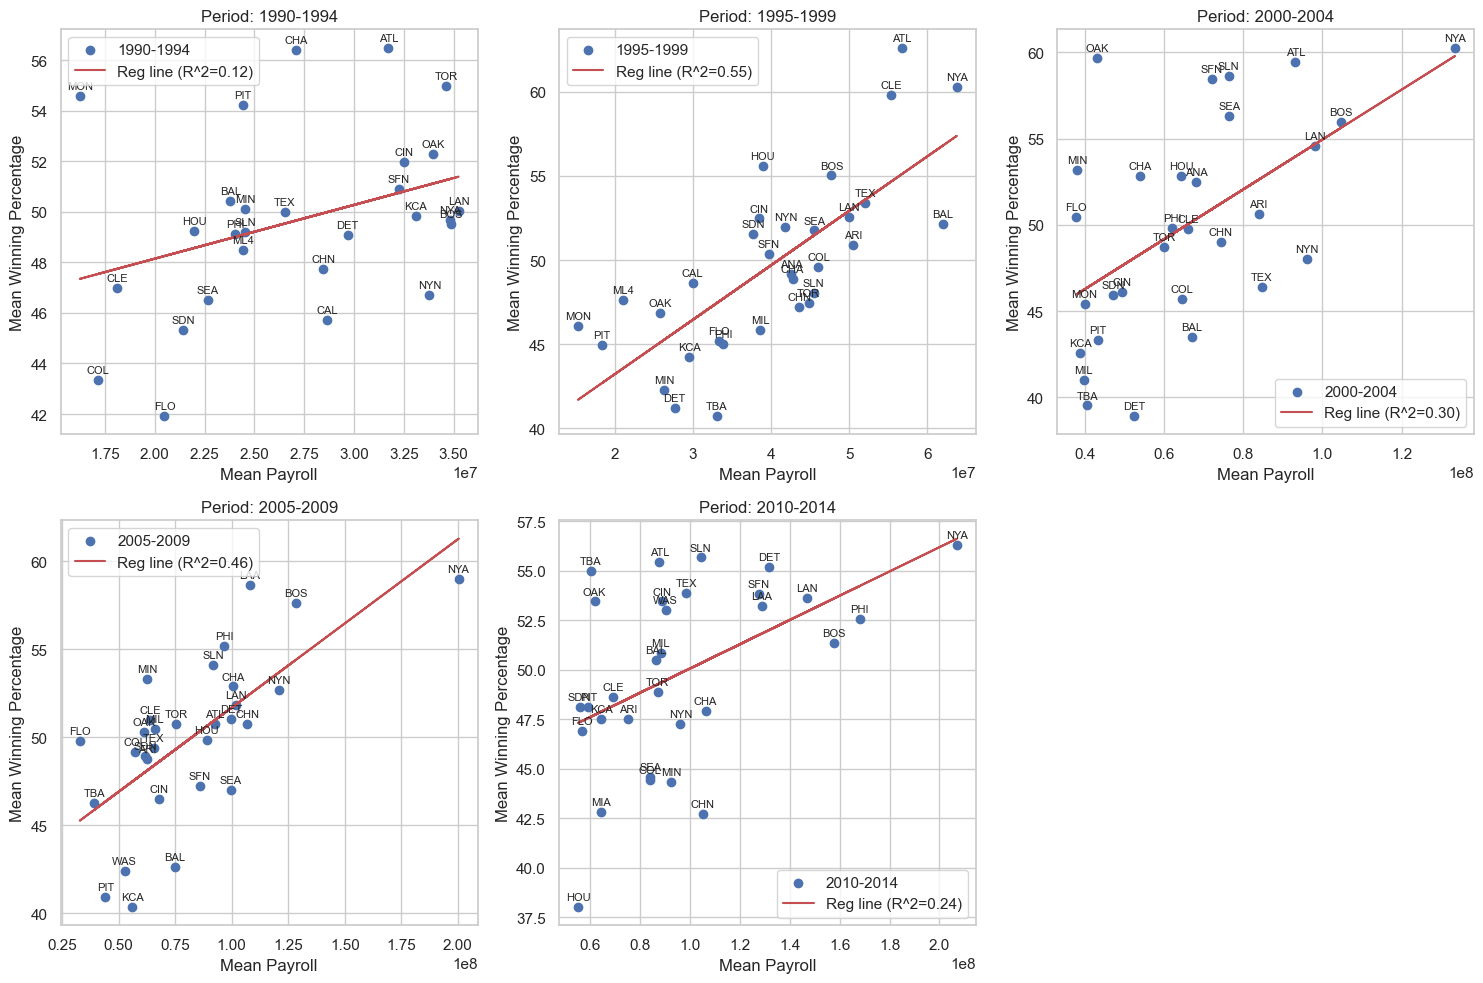

In [108]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

# Step 1: Load your dataset
data = df_filtered.copy()

# Step 2: Discretize the years into five periods using pandas.cut
bins = [1989, 1994, 1999, 2004, 2009, 2014]
labels = ['1990-1994', '1995-1999', '2000-2004', '2005-2009', '2010-2014']
data['Period'] = pd.cut(data['yearID'], bins=bins, labels=labels, right=True)

# Step 3: Group data by Period and teamID, calculate mean payroll and winning percentage
grouped = data.groupby(['Period', 'teamID']).agg(
    mean_winning_percentage=('WinningPercentage', 'mean'),
    mean_payroll=('TotalPayroll', 'mean')
).reset_index()

# Step 4: Create scatterplots with regression lines for each period
plt.figure(figsize=(15, 10))  # Set figure size

for i, period in enumerate(labels):
    plt.subplot(2, 3, i+1)  # 5 plots in a grid (2 rows, 3 columns)
    
    # Filter data for the current period
    period_data = grouped[grouped['Period'] == period]
    
    # Check if there are sufficient data points and no NaNs
    period_data = period_data.dropna(subset=['mean_payroll', 'mean_winning_percentage'])
    
    if len(period_data) < 2:
        # If less than 2 points, skip regression (not enough data to fit a line)
        plt.title(f'Period: {period} (Not enough data)')
        plt.scatter(period_data['mean_payroll'], period_data['mean_winning_percentage'], color='b')
        continue

    # Scatter plot
    plt.scatter(period_data['mean_payroll'], period_data['mean_winning_percentage'], label=period, color='b')

    # Add a regression line (handle cases with constant data)
    if period_data['mean_payroll'].nunique() > 1:  # Check if there's variation in mean_payroll
        slope, intercept, r_value, p_value, std_err = linregress(
            period_data['mean_payroll'], period_data['mean_winning_percentage']
        )
        # Plot regression line
        plt.plot(
            period_data['mean_payroll'],
            intercept + slope * period_data['mean_payroll'],
            'r', label=f'Reg line (R^2={r_value**2:.2f})'
        )
    else:
        plt.title(f'Period: {period} (No variation in payroll)')
    
    # Annotate each point with its teamID
    for idx, row in period_data.iterrows():
        plt.annotate(row['teamID'], (row['mean_payroll'], row['mean_winning_percentage']),
                     textcoords="offset points", xytext=(0,5), ha='center', fontsize=8)

    # Add plot titles and labels
    plt.title(f'Period: {period}')
    plt.xlabel('Mean Payroll')
    plt.ylabel('Mean Winning Percentage')
    plt.legend()

# Step 5: Adjust layout and display the plot
plt.tight_layout()
plt.show()


#### Question 2
Analysing Oakland A's spending efficiency compared to other teams:

We compare Oakland A's spending efficiency vs other teams by using a condition to plot the data points for Oakland A's in orange color with a black border.<br>
This makes it easier to identify and compare the data points of Oakland compared to other teams.

C:\Users\srini\AppData\Local\Temp\ipykernel_35988\3953521909.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(['Period', 'teamID']).agg(


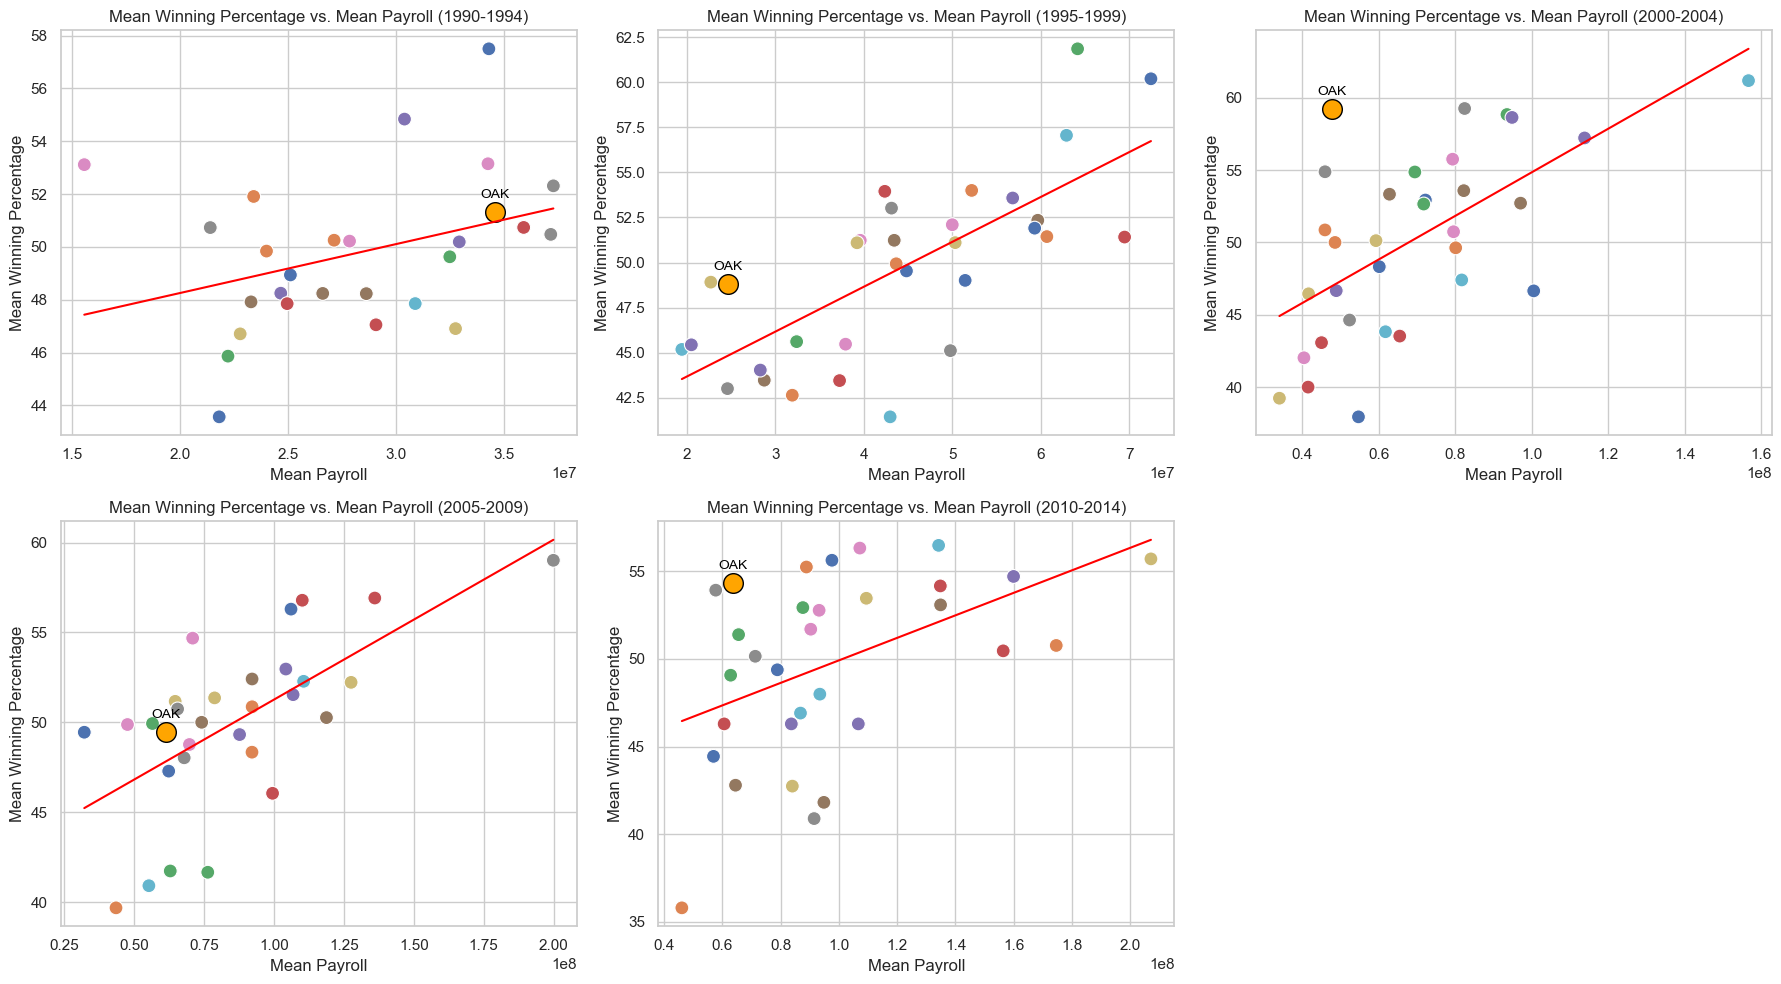

In [109]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Assuming df_filtered is already loaded
df = df_filtered.copy()

# Step 1: Discretize the year into 5 periods
time_periods = [1989, 1995, 2000, 2005, 2010, 2015]  # 5 periods: 1990-1994, 1995-1999, etc.
df['Period'] = pd.cut(df['yearID'], bins=time_periods, labels=['1990-1994', '1995-1999', '2000-2004', '2005-2009', '2010-2014'])

# Step 2: Group by Period and Team, then calculate mean Winning Percentage and Payroll
grouped = df.groupby(['Period', 'teamID']).agg(
    Mean_Winning_Percentage=('WinningPercentage', 'mean'),
    Mean_Payroll=('TotalPayroll', 'mean')
).reset_index()

# Step 3: Create subplots for each period with a regression line
sns.set(style='whitegrid')

# Define the number of rows and columns for subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()  # Flatten axes to easily index them

# Loop through each period and create scatter plots in subplots
for idx, period in enumerate(grouped['Period'].unique()):
    period_data = grouped[grouped['Period'] == period].dropna(subset=['Mean_Payroll', 'Mean_Winning_Percentage'])
    
    # Check if there are at least 2 data points after dropping NaNs
    if len(period_data) < 2:
        print(f"Skipping period {period} due to insufficient data points")
        continue
    
    ax = axes[idx]  # Select the subplot axes for this period

    # Scatter plot
    sns.scatterplot(data=period_data, x='Mean_Payroll', y='Mean_Winning_Percentage', 
                    hue='teamID', s=100, palette='deep', legend=False, ax=ax)
    
    # Highlight 'OAK' team
    oak_data = period_data[period_data['teamID'] == 'OAK']
    
    if not oak_data.empty:
        ax.scatter(oak_data['Mean_Payroll'], oak_data['Mean_Winning_Percentage'], 
                   color='orange', s=200, label='OAK', edgecolor='black')
        # Annotate 'OAK'
        for idx_oak, row in oak_data.iterrows():
            ax.annotate('OAK', (row['Mean_Payroll'], row['Mean_Winning_Percentage']),
                        textcoords="offset points", xytext=(0,10), ha='center', fontsize=10, color='black')

    # Sort the data by Mean_Payroll for a better regression line
    period_data = period_data.sort_values(by='Mean_Payroll')
    
    # Check if there's variation in Mean_Payroll before fitting the regression line
    if period_data['Mean_Payroll'].nunique() > 1:
        # Add regression line
        slope, intercept, r_value, p_value, std_err = linregress(period_data['Mean_Payroll'], period_data['Mean_Winning_Percentage'])
        
        # Create x values for regression line
        x_values = np.linspace(period_data['Mean_Payroll'].min(), period_data['Mean_Payroll'].max(), 100)
        reg_line = slope * x_values + intercept
        
        # Plot the regression line
        ax.plot(x_values, reg_line, color='red', label=f'Regression line (R²={r_value**2:.2f})')
    else:
        ax.set_title(f'Period: {period} (No variation in payroll)')
    
    # Titles and labels
    ax.set_title(f'Mean Winning Percentage vs. Mean Payroll ({period})')
    ax.set_xlabel('Mean Payroll')
    ax.set_ylabel('Mean Winning Percentage')

# Remove unused subplot (since we have 5 periods but used a 2x3 grid)
axes[-1].axis('off')

# Adjust layout for better spacing
plt.tight_layout()
plt.show()


<b>General Trends:<b>

1) Across all time periods, there’s a clear positive relationship between payroll and winning percentage (indicated by the red trendline). Teams that spend more on payroll tend to have a higher winning percentage, which is generally expected.

2) Mean payrolls increase significantly over time, from the 1990-1994 period (where payrolls are in the range of 15 million USD  to 40 million USD) to 2010-2014 (where payrolls go up to $200 million). The trend reflects rising salaries in Major League Baseball over the decades.

3) There is significant variability in how efficiently teams translate payroll into wins. Some teams have a relatively low payroll but achieve high winning percentages, while others spend more but don’t perform as well.


<b>Oakland A’s (OAK) Spending Efficiency:<b>
The Oakland A’s are highlighted in each of the time periods, showing a distinct pattern:

1990-1994: Oakland is positioned with a moderate payroll (around $35 million) and a mean winning percentage around 52%. They are close to the trendline, indicating average spending efficiency.

1995-1999: The A's have a relatively low payroll compared to other teams (around $20 million) and a winning percentage around 48%. They are positioned above the trendline, which indicates that their despite their low spending, they have many wins during this period.

2000-2004: This period marks a standout performance for the Oakland A’s. Despite a relatively low payroll (around $50 million), they achieve a high winning percentage of about 58%, well above the trendline. This period reflects the success of their "Moneyball" strategy, where they focused on maximizing efficiency through data-driven player evaluation.

2005-2009: The A’s again have a lower payroll (around $70 million) and a winning percentage around 50%, slightly above the trendline. While they are no longer overperforming as dramatically as in the previous period, they are still managing to be more efficient than most teams relative to their payroll.

2010-2014: Oakland remains in the lower half of payrolls (around $70 million) but achieves a winning percentage of around 54%, above the trendline once more. This suggests that they continue to achieve better-than-expected performance despite limited spending.

<b> Summary of Oakland A's Efficiency:</b> <br>
2000-2004 is the standout period for Oakland, where they outperformed expectations by a significant margin given their low payroll.
Throughout the other periods, the A’s generally maintain lower payrolls but consistently perform above the trendline, indicating strong efficiency in converting spending into wins.

#### Problem 5: Calculating standardized payroll

This code block calculates the average and standard deviation of payroll per year using the groupby function and then calculates the standardized payroll value.

We then average the values of the standardized payroll per year and store it in the team_avg_standardized_payroll column.

In [110]:
# Step 1: Load your dataset
yearly_stats = df_filtered.groupby('yearID')['TotalPayroll'].agg(['mean', 'std']).reset_index()
yearly_stats.columns = ['yearID', 'avg_payroll', 'std_payroll']

# Step 2: Merge with the main DataFrame
merged_df = pd.merge(df_filtered, yearly_stats, on='yearID', how='left')
merged_df['standardized_payroll'] = (merged_df['TotalPayroll'] - merged_df['avg_payroll']) / merged_df['std_payroll']
avg_payroll = merged_data.groupby(['Period', 'teamID'])['standardized_payroll'].transform('mean')
merged_data['team_avg_standardized_payroll'] = avg_payroll


C:\Users\srini\AppData\Local\Temp\ipykernel_35988\2992048597.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_payroll = merged_data.groupby(['Period', 'teamID'])['standardized_payroll'].transform('mean')


#### Problem 6 : Plot of mean winning percentage vs standardized payroll

This code creates scatterplots of Mean Winning Percentage vs. Mean Standardized Payroll. It follows the same approach as in Problem 4, but replaces mean_payroll with standardized_payroll.

C:\Users\srini\AppData\Local\Temp\ipykernel_35988\233159676.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = data.groupby(['Period', 'teamID']).agg(
C:\Users\srini\AppData\Local\Temp\ipykernel_35988\233159676.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_payroll = merged_data.groupby(['Period', 'teamID'])['standardized_payroll'].transform('mean')


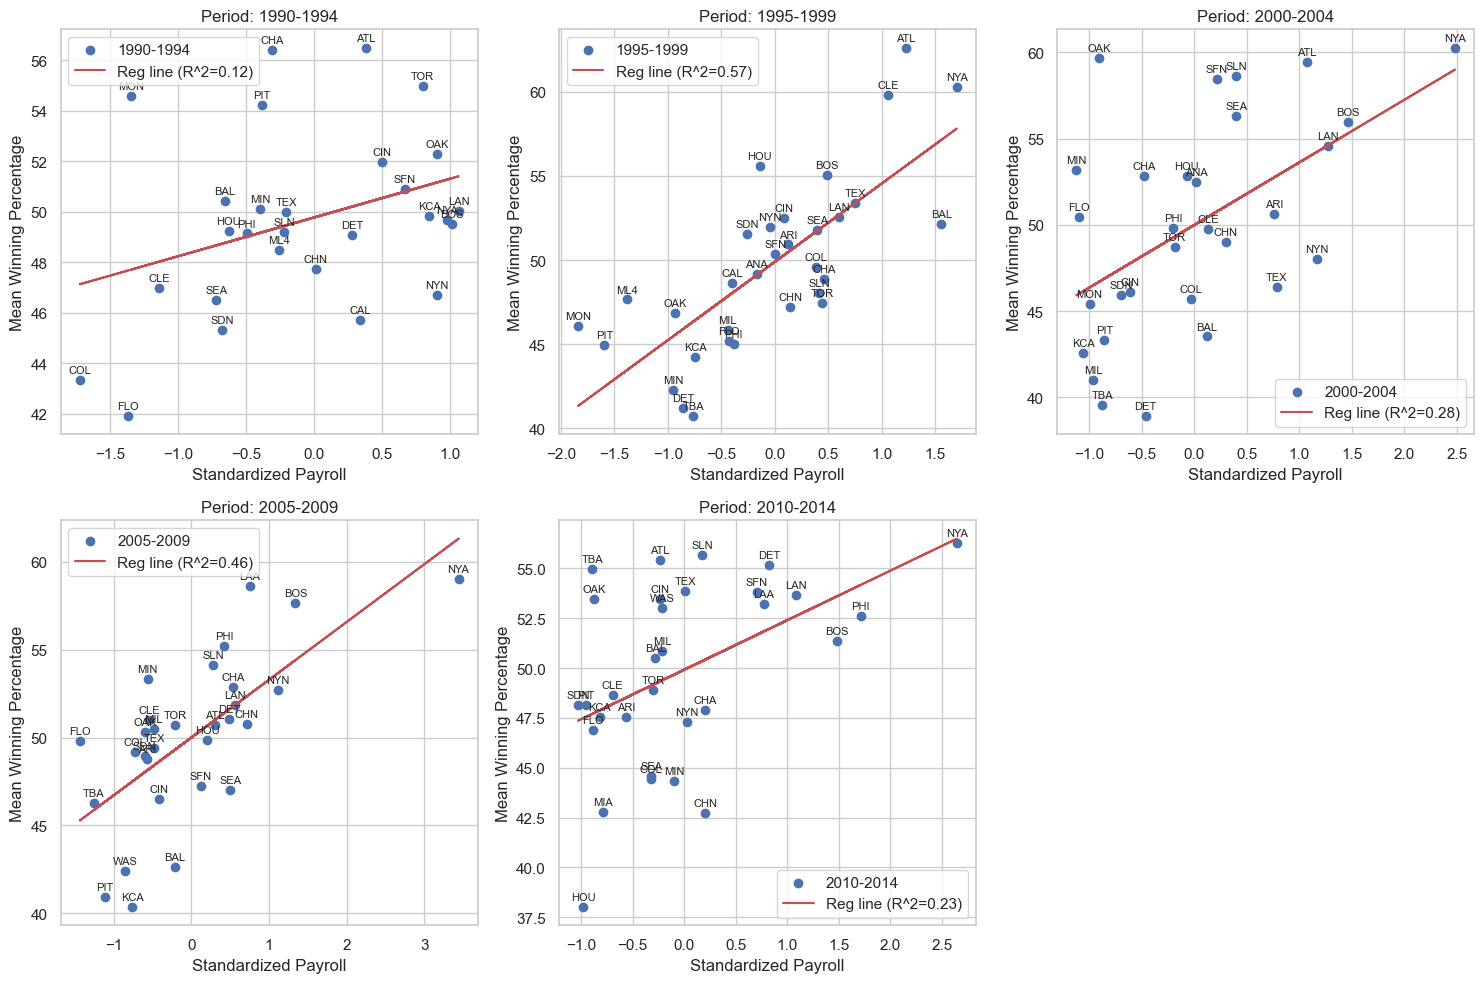

In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress


data = merged_df.copy()
data = data[(data['yearID'] >= 1990) & (data['yearID'] <= 2014)]

# Discretize the years into five periods using pandas.cut
bins = [1989, 1994, 1999, 2004, 2009, 2014]
labels = ['1990-1994', '1995-1999', '2000-2004', '2005-2009', '2010-2014']
data['Period'] = pd.cut(data['yearID'], bins=bins, labels=labels, right=True)

# Step 3: Group data by Period and teamID, calculate mean winning percentage (but use raw standardized payroll)
grouped = data.groupby(['Period', 'teamID']).agg(
    mean_winning_percentage=('WinningPercentage', 'mean')
).reset_index()

# Step 4: Merge grouped mean_winning_percentage with the original data to keep raw standardized payroll
merged_data = pd.merge(data[['Period', 'teamID', 'standardized_payroll']], grouped, on=['Period', 'teamID'], how='inner')
avg_payroll = merged_data.groupby(['Period', 'teamID'])['standardized_payroll'].transform('mean')
merged_data['team_avg_standardized_payroll'] = avg_payroll

# Keeping only one entry per period-team combination
merged_data = merged_data.drop_duplicates(subset=['Period', 'teamID'])

merged_data.dropna(inplace=True)

# Step 5: Create scatterplots with regression lines for each period using standardized payroll and mean winning percentage
plt.figure(figsize=(15, 10))  # Set figure size for 5 plots

for i, period in enumerate(merged_data['Period'].unique()):
    plt.subplot(2, 3, i+1)  # 5 plots in a grid (2 rows, 3 columns)
    
    # Filter data for the current period
    period_data = merged_data[merged_data['Period'] == period]
    
    # Check if there are sufficient data points and no NaNs
    period_data = period_data.dropna(subset=['team_avg_standardized_payroll', 'mean_winning_percentage'])
    
    if len(period_data) < 2:
        # If less than 2 points, skip regression (not enough data to fit a line)
        plt.title(f'Period: {period} (Not enough data)')
        plt.scatter(period_data['team_avg_standardized_payroll'], period_data['mean_winning_percentage'], hue='yearID')
        continue

    # Scatter plot
    plt.scatter(period_data['team_avg_standardized_payroll'], period_data['mean_winning_percentage'], label=period)

    # Add a regression line (handle cases with constant data)
    if period_data['team_avg_standardized_payroll'].nunique() > 1:  # Check if there's variation in standardized payroll
        slope, intercept, r_value, p_value, std_err = linregress(
            period_data['team_avg_standardized_payroll'], period_data['mean_winning_percentage']
        )
        # Plot regression line
        plt.plot(
            period_data['team_avg_standardized_payroll'],
            intercept + slope * period_data['team_avg_standardized_payroll'],
            'r', label=f'Reg line (R^2={r_value**2:.2f})'
        )
    else:
        plt.title(f'Period: {period} (No variation in payroll)')
    for idx, row in period_data.iterrows():
        plt.annotate(row['teamID'], (row['team_avg_standardized_payroll'], row['mean_winning_percentage']),
                     textcoords="offset points", xytext=(0,5), ha='center', fontsize=8)
    # Add plot titles and labels
    plt.title(f'Period: {period}')
    plt.xlabel('Standardized Payroll')
    plt.ylabel('Mean Winning Percentage')
    plt.legend()

# Step 6: Hide the 6th subplot (bottom right) since there are only 5 periods
plt.subplot(2, 3, 6).axis('off')

# Step 7: Adjust layout and display the plot
plt.tight_layout()
plt.show()


In Problem 6, the payroll has been standardized, putting the payroll on a relative scale where each team's payroll is compared to the average payroll across the league for that period.

The resulting x-axis values are centered around 0, with negative values indicating teams with below-average payrolls and positive values for teams with above-average payrolls.<br>

<b>Effects of standardization:</b> <br>
1) Teams that spend significantly above or below the average are now expressed in units relative to the league average, making it easier to see how teams fare against the average.<br>
2) Standardization likely smooths out extreme payroll values, reducing the impact of a few large-spending teams on the visualization. <br>
3) The regression line in each plot suggests a general upward trend, meaning higher payrolls generally correlate with higher winning percentages across the periods. The varying R² values suggest that payroll's predictive power fluctuates by period, with some periods showing stronger correlations than others (e.g., 1995–1999 has a stronger relationship than 2010–2014).

#### Problem 7

Plot of winning percentage (y-axis) vs. standardized payroll (x-axis)

This code generates a scatter plot that shows the relationship between standardized payroll and winning percentage for different baseball teams. It also includes a regression line that represents the overall trend across all teams. This visualization helps assess whether higher payrolls generally lead to higher winning percentages, as well as how individual teams perform relative to the overall trend.

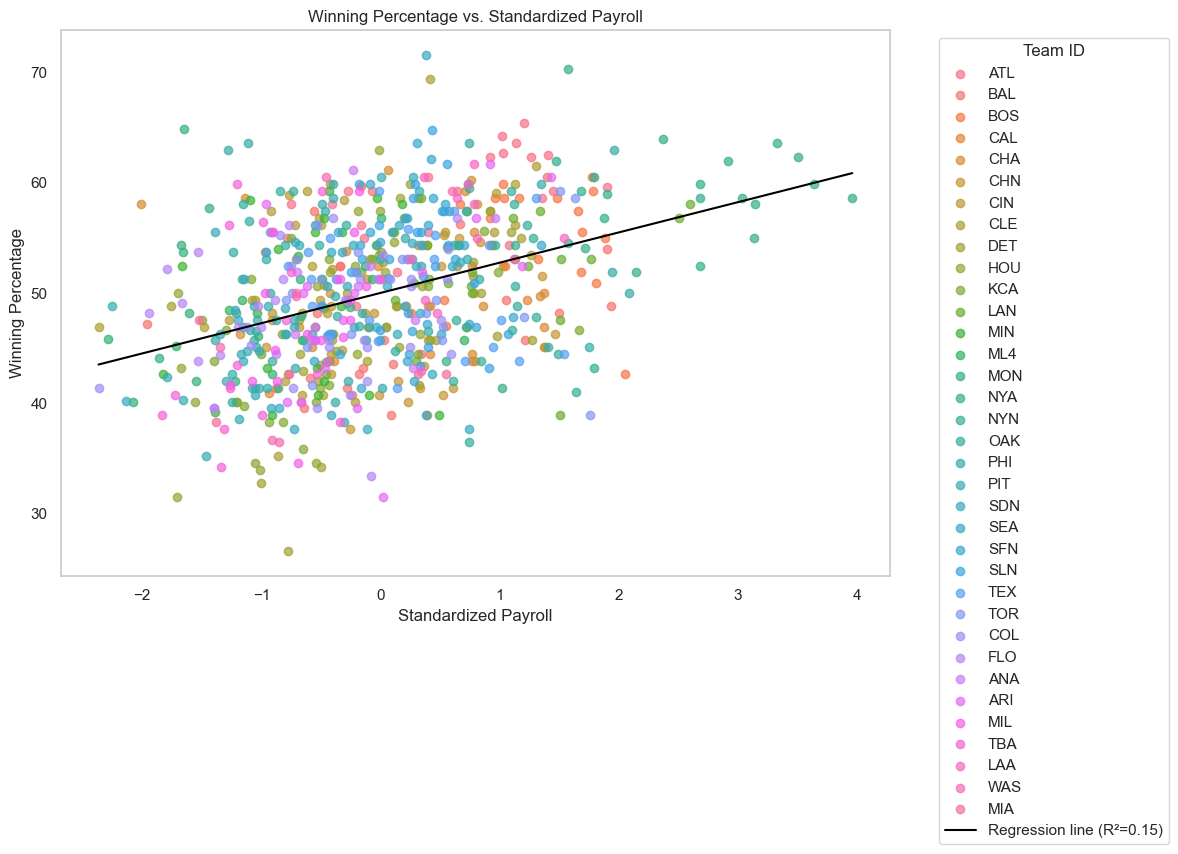

In [112]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
import seaborn as sns

# Step 1: Load your dataset (assuming df_filtered is your DataFrame)
data = merged_df.copy()

# Step 2: Create a scatter plot of standardized payroll vs. winning percentage
plt.figure(figsize=(12, 8))

# Step 3: Use a scatter plot with different colors for each team
# Use seaborn to get a color palette
palette = sns.color_palette("husl", len(data['teamID'].unique()))

# Create a scatter plot, using teamID for color
for team, color in zip(data['teamID'].unique(), palette):
    team_data = data[data['teamID'] == team]
    plt.scatter(team_data['standardized_payroll'], 
                team_data['WinningPercentage'], 
                color=color, 
                alpha=0.7, 
                label=team)

# Step 4: Add a regression line for the entire dataset
slope, intercept, r_value, p_value, std_err = linregress(data['standardized_payroll'], data['WinningPercentage'])
x_values = np.linspace(data['standardized_payroll'].min(), data['standardized_payroll'].max(), 100)
regression_line = slope * x_values + intercept

# Plot the regression line
plt.plot(x_values, regression_line, color='black', label=f'Regression line (R²={r_value**2:.2f})')

# Step 5: Customize the plot
plt.title('Winning Percentage vs. Standardized Payroll')
plt.xlabel('Standardized Payroll')
plt.ylabel('Winning Percentage')
plt.legend(title='Team ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()

# Step 6: Show the plot
plt.tight_layout()
plt.show()


In [113]:
print("Slope of regression line:", slope)
print("Intercept of regression line:", intercept)

Slope of regression line: 2.7478145870693136
Intercept of regression line: 49.988553148430135


#### Problem 8

Creating a new field to compute each team's spending effiency and plotting against time

This code generates a line plot to visualize the efficiency of five specific baseball teams over time, from 1990 to 2014. The efficiency is calculated as the difference between a team's actual winning percentage and its expected winning percentage based on its payroll.

The plot shows how efficient each team has been from 1990 to 2014. <br>

Efficiency represents how well a team performed relative to its payroll-based expectations: <br>
1.Positive values (above 0) indicate that a team performed better than expected based on its payroll.<br>
2.Negative values (below 0) indicate underperformance relative to payroll.<br>


By plotting this over time, we can see how teams like Oakland ("OAK") performed during the "Moneyball" era, when they were known for achieving high efficiency despite low payrolls. Other teams like the Yankees ("NYA"), Red Sox ("BOS"), Braves ("ATL"), and Rays ("TBA") are also tracked for comparison.

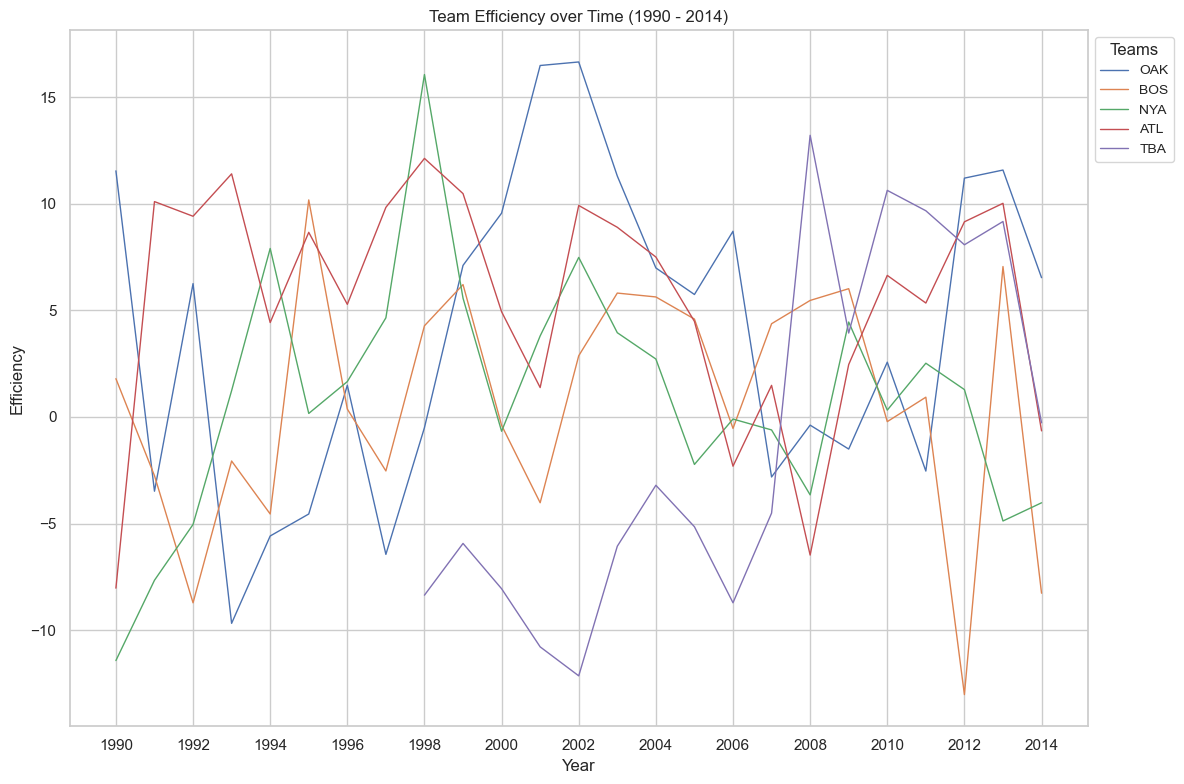

In [114]:
# Calculating expected win percentage and efficiency using data from above cell
data['expected_win_pcy']=slope*data['standardized_payroll']+ intercept
data['efficiency']=data['WinningPercentage']-data['expected_win_pcy']
df_filtered = data

# Set the plot style for better aesthetics
sns.set(style="whitegrid")

# Create the line plot for each team
plt.figure(figsize=(12, 8))

# Plotting a line for each team's payroll over the years
for team in ['OAK', 'BOS', 'NYA', 'ATL', 'TBA']:
    team_data = df_filtered[df_filtered['teamID'] == team]
    plt.plot(team_data['yearID'], team_data['efficiency'], label=team, linewidth=1)

# Adding labels and title
plt.xlabel('Year')
plt.ylabel('Efficiency')
plt.title('Team Efficiency over Time (1990 - 2014)')
plt.xticks(range(1990, 2015, 2))  # Setting x-ticks for every 2 years

# Optional: Add a legend outside the plot for team labels
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), title='Teams', fontsize='small')

# Display the plot
plt.tight_layout()
plt.show()


<b>Oakland's Performance (OAK, Blue Line):

<b>Pre-Moneyball Era (before 2000):</b> Oakland's efficiency fluctuated greatly during the 1990s, with several years of negative efficiency (below 0), meaning their performance was suboptimal compared to payroll and resources. <br>
<b>Moneyball Period (2002-2004):</b> Oakland's efficiency spiked sharply during the early 2000s, a period associated with the Moneyball era (highlighted in 2002 and 2003 in particular). Oakland reached high efficiency levels, peaking well above other teams. This reflects how they were able to outperform expectations based on their relatively low payroll.  <br>
The rise in efficiency during this period is a direct outcome of the Moneyball strategy, where the Athletics used data analytics to identify undervalued players and maximize their performance with minimal financial investment.  <br>
<b>Post-Moneyball Era:</b> After 2004, Oakland's efficiency shows a gradual decline with fluctuations, but it remains positive in several years, indicating that the team still managed to stay relatively efficient compared to their payroll.  <br>

In conclusion, Oakland's Moneyball strategy was highly effective in improving efficiency during the early 2000s, as seen by their dramatic improvement and relative outperformance compared to other teams in the league during that period.